<a href="https://colab.research.google.com/github/miffylim2308/ADALL_github/blob/main/ADALL_My_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color = 'red'>**dated 25.07.2026 7pm**


- Ctrl + / to remark/unremark
- Ctrl + ] to ident right
- Ctrl + [ to indet left

#**Session 1: From business problem to clean dataset**

#**Chapter 1. Setup and load libraries**

In [12]:
# Core Libraries
import os
import shutil
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Modelling libraries and preprocessing
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

RANDOM_STATE = 42

#mse = mean_squared_error(y_true, y_pred)
#rmse = np.sqrt(mse)

print('Setup complete')
# Make wide tables easier to read in Colab
pd.set_option('display.max_columns', 100)

Setup complete


#**Chapter 2. Load the dataset**

In [3]:
#Load dataset from github
github_raw_url = 'https://raw.githubusercontent.com/rq-goh/ADALL_github/refs/heads/main/laptop_prices_2024_sgd_TL.csv'

df = pd.read_csv(github_raw_url)

print('Dataset loaded successfully.')
print('Shape:', df.shape)
display(df.head())

#Load dataset from kaggle
#path = kagglehub.dataset_download("devansodariya/student-performance-data")
#print("Downloaded to:", path)
#print(os.listdir(path))
#df = pd.read_csv(os.path.join(path, "student_data.csv"))

# This cell loads the laptop price dataset directly from GitHub.
# The GitHub raw URL points to the actual CSV file, not the normal GitHub preview page.
# pd.read_csv() reads the CSV file and stores it as a pandas DataFrame called df.
# df.shape shows the number of rows and columns in the dataset.
# df.head() displays the first 5 rows so we can quickly check that the data loaded correctly.

Dataset loaded successfully.
Shape: (1000, 15)


,Unnamed: 0,Brand,Model,CPU,GPU,RAM_GB,Storage_Type,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
0,0,Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,SSD,256,False,1.56,16.0,5.28,3207.60,80,160.38
1,1,Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,SSD,1024,True,1.45,14.0,6.01,2568.40,80,179.79
2,2,Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,SSD,2048,False,1.34,14.0,6.56,2050.80,80,143.56
3,3,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,SSD,4096,True,1.18,13.3,4.62,2477.59,80,173.43
4,4,Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,SSD,1024,True,1.31,14.0,4.81,2626.40,80,183.85


#**Chapter 2a. Set up OpenAI**

In [4]:
# Default method: copy the prompt into the chatbot manually.
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

# Only use this section if your tutor has asked you to call the API from Colab.
# You must first save OPENAI_API_KEY in Colab Secrets.

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

# This cell prepares the notebook to use the OpenAI API, if needed.
# RUN_API_CELLS controls whether the notebook uses the API or manual chatbot mode.
# If RUN_API_CELLS is True, the notebook will try to connect to OpenAI using an API key.
# If RUN_API_CELLS is False, students can copy the prompt and paste it into ChatGPT manually.
# OPENAI_MODEL stores the model name that will be used later when sending prompts.
# client starts as None first, then becomes an OpenAI client after the API key is loaded.
# userdata.get('OPENAI_API_KEY') reads the API key saved in Colab Secrets.
# OpenAI(api_key=api_key) creates the connection object used to call the API.


OpenAI client is ready.


In [5]:
# TESTING THE PROMPT
prompt_test = f"""
I am testing the prompt generator.
"""
print('=== Prompt to send ===')
print(prompt_test[:2000])

if client is not None:
    response_test = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_test
    )
    print('\n=== LLM response ===')
    print(response_test.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

=== Prompt to send ===

I am testing the prompt generator.


=== LLM response ===
Great—what kind of prompt generator are you testing (e.g., for chatbots, image generation, code, tutoring)?

If you share:
1) the goal/topic,  
2) the target audience, and  
3) the desired output format (length, style, variables, etc.),  

…I can generate a few sample prompts to test the system.


#**Chapter 3. LLM-assisted problem framing**

In [6]:
# PROMPT
prompt1 = f"""
You are an expert data scientist with experience in tree-based regression models.
Help me translate this business problem into a modelling objective.

Business problem: A refurbished laptop seller wants to price laptops fairly and consistently.
Dataset context: The dataset contains laptop specifications and price in SGD.

Please answer:
What should the modelling objective be?
What is the most meaningful target column?
Which metric would be easiest to explain to business users?
Who are the main stakeholders?
What are three risks or pitfalls?
"""
print('=== Prompt to send ===')
print(prompt1[:2000])

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt1
    )
    print('\n=== LLM response ===')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.
Help me translate this business problem into a modelling objective.

Business problem: A refurbished laptop seller wants to price laptops fairly and consistently.
Dataset context: The dataset contains laptop specifications and price in SGD.

Please answer:
What should the modelling objective be?
What is the most meaningful target column?
Which metric would be easiest to explain to business users?
Who are the main stakeholders?
What are three risks or pitfalls?


=== LLM response ===
### 1) What should the modelling objective be?
Build a regression model that predicts the **fair market selling price (in SGD)** of a refurbished laptop from its specs, aiming to:

- **Maximize predictive accuracy** on unseen laptops (generalization).
- **Provide consistent pricing** across different configurations and brands.
- **Be robust to outliers** (e.g., very rare models, missing fields) so predi

#<font color='red'>**Chapter 4. Quick dataset inspection before using an LLM**

In [13]:
print('Shape:', df.shape)

display(df.head())

print('\nInfo:')
display(df.info())

print('\nColumns:', df.columns.tolist())

print("\nDescribe:")
display(df.describe(include='all').transpose())

missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

duplicate_count = df.duplicated().sum()
print("\nDuplicate count:", duplicate_count)

Shape: (1000, 10)


,Brand,Model,CPU,GPU,RAM_GB,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Price_SGD
0,Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,256,False,1.56,16.0,3207.60
1,Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,1024,True,1.45,14.0,2568.40
2,Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,2048,False,1.34,14.0,2050.80
3,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,4096,True,1.18,13.3,2477.59
4,Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,1024,True,1.31,14.0,2626.40



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Model             1000 non-null   object 
 2   CPU               1000 non-null   object 
 3   GPU               1000 non-null   object 
 4   RAM_GB            1000 non-null   int64  
 5   Storage_GB        1000 non-null   int64  
 6   Touchscreen       1000 non-null   bool   
 7   Weight_kg         1000 non-null   float64
 8   Screen_Size_inch  1000 non-null   float64
 9   Price_SGD         1000 non-null   float64
dtypes: bool(1), float64(3), int64(2), object(4)
memory usage: 71.4+ KB


None


Columns: ['Brand', 'Model', 'CPU', 'GPU', 'RAM_GB', 'Storage_GB', 'Touchscreen', 'Weight_kg', 'Screen_Size_inch', 'Price_SGD']

Describe:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,1000,6,Asus,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,1000,30,Predator Helios 300,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPU,1000,10,Intel i5-14600H,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GPU,1000,9,NVIDIA RTX 4070,268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAM_GB,1000.0,NaN,NaN,NaN,53.128,44.413288,8.0,16.0,32.0,64.0,128.0
Storage_GB,1000.0,NaN,NaN,NaN,1505.024,1380.203919,256.0,512.0,1024.0,2048.0,4096.0
Touchscreen,1000,2,False,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight_kg,1000.0,NaN,NaN,NaN,2.03656,0.746477,1.0,1.34,1.97,2.68,3.5
Screen_Size_inch,1000.0,NaN,NaN,NaN,15.6457,1.759846,13.3,14.0,15.6,17.3,18.4
Price_SGD,1000.0,NaN,NaN,NaN,2649.26647,704.545395,1359.6,2073.7,2608.2,3185.3,4366.4


Missing values:
 Brand               0
Model               0
CPU                 0
GPU                 0
RAM_GB              0
Storage_GB          0
Touchscreen         0
Weight_kg           0
Screen_Size_inch    0
Price_SGD           0
dtype: int64

Duplicate count: 0


#**Chapter 5. First LLM touchpoint: send only a small preview**

In [14]:
data_preview = df.head(10).to_string()
print(data_preview[:1500])

  Brand                Model                        CPU              GPU  RAM_GB  Storage_GB  Touchscreen  Weight_kg  Screen_Size_inch  Price_SGD
0  Acer             Aspire 5           Intel i9-14900HK  NVIDIA RTX 4070      64         256        False       1.56              16.0    3207.60
1  Acer              Nitro 5         AMD Ryzen 9 8900HX  AMD Radeon 780M      32        1024         True       1.45              14.0    2568.40
2  Acer              Nitro 5          AMD Ryzen 5 8600H  NVIDIA RTX 4050      32        2048        False       1.34              14.0    2050.80
3  Acer        TravelMate P6  Intel Core Ultra 7 15500H  NVIDIA RTX 4060      16        4096         True       1.18              13.3    2477.59
4  Acer  Predator Helios 300            Intel i7-14800H  NVIDIA RTX 4070       8        1024         True       1.31              14.0    2626.40
5  Acer             Aspire 5           Intel i9-14900HK  NVIDIA RTX 4080      32         256        False       3.34        

In [168]:
preview_prompt = f"""
Here are the first 10 rows of a laptop pricing dataset:

{data_preview}

Questions:
1. What does each row appear to represent?
2. Which column is likely the target for a price prediction model?
3. What are 3 possible data quality checks we should perform before modelling?

Keep the answer short and practical.
"""
print('=== Prompt to send ===')
print(preview_prompt[:2000])

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=preview_prompt
    )
    print('\n=== LLM response ===')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

=== Prompt to send ===

Here are the first 10 rows of a laptop pricing dataset:

   Unnamed: 0 Brand                Model                        CPU              GPU  RAM_GB Storage_Type  Storage_GB  Touchscreen  Weight_kg  Screen_Size_inch  Discount_percent  Price_SGD  Brand_Discount  Member_Discount
0           0  Acer             Aspire 5           Intel i9-14900HK  NVIDIA RTX 4070      64          SSD         256        False       1.56              16.0              5.28    3207.60              80           160.38
1           1  Acer              Nitro 5         AMD Ryzen 9 8900HX  AMD Radeon 780M      32          SSD        1024         True       1.45              14.0              6.01    2568.40              80           179.79
2           2  Acer              Nitro 5          AMD Ryzen 5 8600H  NVIDIA RTX 4050      32          SSD        2048        False       1.34              14.0              6.56    2050.80              80           143.56
3           3  Acer        Trav

#<font color='red'>**Chapter 7. Build the payload text**</font>

In [16]:
# Build payload text step by step.
# Payload text is a short profile of the dataset.
# It is safer and smaller than sending the full dataset to the LLM.

payload_text = ''

# 0. Business objective
payload_text += '=== BUSINESS OBJECTIVE ===\n'
payload_text += 'Dataset context: The dataset contains refurbished laptop specifications and price in SGD.\n'
payload_text += 'Business Goal: Predict laptop prices based on laptop specifications.\n'
payload_text += 'Intended Users: Owner of the shop which sells refurbished laptops so needs to set a reasonable and competitive price.\n'
payload_text += 'Questions:\n'
payload_text += '- Which features influence laptop price?\n'
payload_text += '- What data quality issues exist?\n'
payload_text += '- What preprocessing is required?\n\n'

# 1. Shape
payload_text += '=== SHAPE ===\n'
payload_text += 'Rows: ' + str(df.shape[0]) + '\n'
payload_text += 'Columns: ' + str(df.shape[1]) + '\n\n'

# 2. Sample records
payload_text += '=== SAMPLE RECORDS ===\n'
payload_text += df.head(5).to_string(index=False)
payload_text += '\n\n'

# 3. Column names and data types
payload_text += '=== COLUMNS AND DATA TYPES ===\n'
payload_text += df.dtypes.to_string()
payload_text += '\n\n'

# 4. Numeric summary
payload_text += '=== NUMERIC SUMMARY ===\n'
numeric_summary = df.describe(include='number').round(2)
payload_text += numeric_summary.to_string()
payload_text += '\n\n'

# 5. Null summary
payload_text += "=== NULL SUMMARY ===\n"
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
payload_text += null_summary.to_string()
payload_text += '\n\n'

# 6. Missing values
payload_text += '=== MISSING VALUES ===\n'
missing_table = pd.DataFrame()
missing_table['missing_count'] = df.isna().sum()
missing_table['missing_pct'] = (df.isna().sum() / len(df) * 100).round(2)
payload_text += missing_table.to_string()
payload_text += '\n\n'

# 7. Unique values per column
payload_text += '=== UNIQUE VALUES PER COLUMN ===\n'
unique_table = pd.DataFrame()
unique_table['unique_count'] = df.nunique(dropna=False)
payload_text += unique_table.to_string()
payload_text += '\n\n'

# 8 Correlation between numeric columns
payload_text += '=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n'
correlation_table = df.corr(numeric_only=True).round(2)
payload_text += correlation_table.to_string()
payload_text += '\n\n'

# 9. Top 10 values for categorical columns
payload_text += '=== TOP 10 VALUES FOR CATEGORICAL COLUMNS ===\n'

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_columns) == 0:
    payload_text += 'No categorical columns found.\n'
else:
    for col in categorical_columns:
        payload_text += '\nColumn: ' + col + '\n'
        payload_text += df[col].value_counts(dropna=False).head(10).to_string()
        payload_text += '\n'

payload_text += '\n'

# 10. Skewness of numeric columns
payload_text += '=== SKEWNESS OF NUMERIC COLUMNS ===\n'
skew_table = df.select_dtypes(include='number').skew().round(2)
payload_text += skew_table.to_string()
payload_text += '\n\n'

# 11. Outlier summary
payload_text += '=== OUTLIER SUMMARY (IQR METHOD) ===\n'

numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_pct = round(outlier_count / len(df) * 100, 2)

    payload_text += f'{column}: {outlier_count} ({outlier_pct}%)\n'

payload_text += '\n'

# 12. Leakage scan: columns with all unique values
payload_text += "=== POSSIBLE LEAKAGE COLUMNS (UNIQUE FOR EACH ROW) ===\n"
leak_cols = df.columns[df.nunique() == len(df)]
payload_text +=str(list(leak_cols))
payload_text +="\n\n"

# 13. Simple warning checks
payload_text += '=== SIMPLE WARNING CHECKS ===\n'

id_like_columns = []
constant_columns = []

for col in df.columns:
    unique_count = df[col].nunique(dropna=False)

    if unique_count == len(df):
        id_like_columns.append(col)

    if unique_count <= 1:
        constant_columns.append(col)
payload_text += 'Possible ID-like columns: ' + str(id_like_columns) + '\n'
payload_text += 'Constant columns: ' + str(constant_columns) + '\n'
duplicate_count = df.duplicated().sum()
duplicate_pct = round(duplicate_count / len(df) * 100, 2)
payload_text += (
    f'Duplicate rows: {duplicate_count} ({duplicate_pct}%)\n'
)

print(payload_text)

# This cell builds a short dataset profile called payload_text.
# Instead of sending the full dataset to the LLM, we send summary information only.
# The payload includes shape, column types, numeric summary, missing values, unique counts, correlations, and common category values.
# It also adds simple warning checks for possible ID-like columns, constant columns, and duplicate rows.
# This helps the LLM comment on data readiness without needing every row of the dataset.

=== BUSINESS OBJECTIVE ===
Dataset context: The dataset contains refurbished laptop specifications and price in SGD.
Business Goal: Predict laptop prices based on laptop specifications.
Intended Users: Owner of the shop which sells refurbished laptops so needs to set a reasonable and competitive price.
Questions:
- Which features influence laptop price?
- What data quality issues exist?
- What preprocessing is required?

=== SHAPE ===
Rows: 1000
Columns: 10

=== SAMPLE RECORDS ===
Brand               Model                       CPU             GPU  RAM_GB  Storage_GB  Touchscreen  Weight_kg  Screen_Size_inch  Price_SGD
 Acer            Aspire 5          Intel i9-14900HK NVIDIA RTX 4070      64         256        False       1.56              16.0    3207.60
 Acer             Nitro 5        AMD Ryzen 9 8900HX AMD Radeon 780M      32        1024         True       1.45              14.0    2568.40
 Acer             Nitro 5         AMD Ryzen 5 8600H NVIDIA RTX 4050      32        2048    

# <font color='red'>**Chapter 8. Ask the LLM to review data quality using payload text**


In [17]:
prompt_quality = f"""
You are an expert data scientist with extensive knowledge of tree-based models.
Always justify recommendations using reasoning trace based ONLY on the dataset profile.
============================
DATASET PROFILE
============================
{payload_text}

============================
TASK
============================
Assess the dataset's quality and modelling readiness.

1. Identify all confirmed data quality or modelling-readiness issues.

For each issue, provide:
- Issue
- Column(s) affected
- Evidence from the dataset profile
- Why it may affect analysis or modelling
- Recommended action
- Priority (High / Medium / Low)

2. Identify any potential issues that require further investigation but cannot be confirmed from the dataset profile alone.

3. Highlight the strengths of the dataset (for example, no missing values, no duplicates, appropriate data types, etc.).

4. State whether the dataset is ready for machine learning modelling using ONE of the following ratings:
- Ready
- Ready with Minor Cleaning
- Ready with Moderate Cleaning
- Not Ready
Provide a brief justification.

5. Recommend the Top 3 next steps before modelling.

6. Provide a python script to handle the identified issues.
- Define one helper function for each issue.
- Then define a wrapper function that calls these helper with true false option as user choice
- Provide a single line of code to run the overall wrapper function.
- Do not encode categorical columns or model first.

========================
IMPORTANT INSTRUCTIONS
========================

- Use only the information contained in the dataset profile.
- Do NOT assume information that is not provided.
- If evidence is unavailable, state "Not available" instead of guessing.
- Reference the relevant dataset profile section whenever possible (e.g., Missing Values, Numeric Summary, Correlation Matrix, Warning Checks).
- Do NOT recommend dropping a column solely because it appears in a warning.
- Treat ID-like, high-cardinality, constant, near-constant and outlier warnings as items requiring investigation, not automatic removal.
- Do NOT treat correlation as proof of causation.
- Do NOT recommend removing outliers unless there is evidence they are invalid or unsuitable for the business objective.
- If skewness, outlier summary, feature importance, or other analyses are not included in the dataset profile, state that they were not available instead of inferring results.
- Distinguish clearly between confirmed issues and potential issues.
- Keep recommendations practical, concise, and suitable for a data analytics student.

========================
OUTPUT FORMAT
========================

Overall Modelling Readiness
---------------------------
Readiness Rating:
Brief Justification:

Confirmed Issues
----------------
For each issue, use the following format:

Issue:
Column(s):
Evidence:
Impact:
Recommended Action:
Priority:

Potential Issues Requiring Investigation
-----------------------------------------
For each potential issue, use:

Issue:
Reason Further Investigation is Needed:

Dataset Strengths
-----------------
- ...
- ...
- ...

Checks with No Issues
---------------------
- ...
- ...
- ...

Top 3 Recommended Next Steps
----------------------------
1.
2.
3.

Overall Summary
---------------
Provide a concise summary (3–5 sentences) describing the dataset's overall quality and readiness for machine learning modelling.
"""

if client is not None:
    response_quality= client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_quality
    )
    print('\n=== LLM response ===')
    print(response_quality.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

# This cell asks the LLM to review the dataset profile for modelling-readiness issues.
# The LLM does not receive the full dataset, only the summary stored in payload_text.
# The prompt asks for possible issues and practical remedies.
# The instructions help prevent the LLM from making unsupported assumptions or dropping columns too quickly.
# If the API client is connected, the prompt is sent automatically.
# Otherwise, students can copy the prompt and use the chatbot manually.


=== LLM response ===
Overall Modelling Readiness
---------------------------
**Readiness Rating:** **Ready with Minor Cleaning**  
**Brief Justification:** The dataset has **no missing values**, **no duplicates**, and **no outliers flagged by IQR**, and the target (`Price_SGD`) is present with no nulls. However, there are **confirmed modelling-readiness issues** around **high-cardinality/compound categorical variables** (e.g., `CPU`, `GPU`, `Model`, `Model` strings) and **numeric feature scale/validity concerns** that require validation (e.g., whether `Weight_kg`/`Screen_Size_inch` units and ranges are correct). Correlations with numeric columns are limited and some numeric correlations are near-zero, suggesting the main signal may be in categorical/text-like fields that need careful handling.

Confirmed Issues
----------------
### 1) Issue: Categorical fields are likely “high-cardinality” and may need structured cleaning/standardization
- **Column(s):** `Brand`, `Model`, `CPU`, `GPU`

#<font color='red'>**COPY the Output from above and output Python codes to clean your dataset**

In [18]:
prompt_clean = f"""
You are an expert data scientist with experience in tree-based regression models.
Generate simple and executable python code to fix each of the following issues, only for data cleaning purposes, do not model yet.
Target is ccolumn Price_SGD
Input is df, and output should be cleaned_df.
Issues:
{response_quality.output_text}

Additionally, generate code for:
- remove Possible ID-like columns, Constant columns, Discount-related columns
Lastly, show the columns of df and cleaned_df, to compare the differences, i.e. which columns are added or removed

"""
## below are optionals... ##
#Additionally, generate code for:
#- safe column checks
#- Extreme sparsity / large cardinality in categoricals
#- Robust outlier clipping (only for plausibly bounded numeric features)
#- Apply clipping to numeric predictors only (exclude target if present)
#- ensure no accidental all-null columns
## ---------------------------------##

if client is not None:
    response_clean = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_clean
    )
    print('\nLLM response:')
    print(response_clean.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


LLM response:
```python
import pandas as pd
import numpy as np

def preprocess_laptop_price_data(df):
    """
    Data cleaning only (no encoding, no modeling).
    Produces cleaned_df and a set of reports in addition to the cleaned data.
    """
    cleaned_df = df.copy()
    reports = {}

    # -----------------------------
    # 1) Remove duplicates (safe no-op if already none)
    # -----------------------------
    before_n = len(cleaned_df)
    cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)
    reports["duplicate_rows_removed"] = {"before": before_n, "after": len(cleaned_df)}

    # -----------------------------
    # 2) Basic missingness check (safe no-op)
    # -----------------------------
    reports["missing_value_counts"] = cleaned_df.isna().sum().sort_values(ascending=False)

    # -----------------------------
    # 3) Remove obvious ID-like columns, constant columns
    #    (heuristic only; no columns removed if none match)
    # ---------------------

In [21]:
import pandas as pd

# ----------------------------
# Data cleaning only (no modeling)
# Target: Price_SGD
# Input: df
# Output: cleaned_df
# ----------------------------

def clean_for_modelling(
    df: pd.DataFrame,
    target_col: str = "Price_SGD",
    drop_id_like: bool = True,
    drop_constant: bool = True,
    drop_discount_related: bool = False,  # set True only if you want the discount-feature columns removed
    verbose: bool = True,
) -> pd.DataFrame:
    cleaned_df = df.copy()

    original_cols = set(cleaned_df.columns)

    # ---- 1) Remove ID-like columns (confirmed: Unnamed: 0) ----
    if drop_id_like:
        # Safe heuristics: explicitly drop known id-like columns + any column with "id-like" naming
        id_like_candidates = []
        if "Unnamed: 0" in cleaned_df.columns:
            id_like_candidates.append("Unnamed: 0")
        id_like_candidates += [
            c for c in cleaned_df.columns
            if c.lower() in {"id", "identifier", "index"} or "unnamed" in c.lower()
        ]
        id_like_candidates = sorted(set(id_like_candidates))

        # Also drop any column that is perfectly unique per row (typical row-id proxy)
        # Only if it is not the target.
        n = len(cleaned_df)
        unique_per_row = [
            c for c in cleaned_df.columns
            if c != target_col and cleaned_df[c].nunique(dropna=False) == n
        ]

        id_like_to_drop = sorted(set(id_like_candidates).union(unique_per_row))
        if id_like_to_drop:
            cleaned_df = cleaned_df.drop(columns=id_like_to_drop)
    # ---- 2) Drop constant columns (confirmed: Storage_Type) ----
    if drop_constant:
        constant_cols = [
            c for c in cleaned_df.columns
            if cleaned_df[c].nunique(dropna=False) <= 1
        ]
        if constant_cols:
            cleaned_df = cleaned_df.drop(columns=constant_cols)

    # ---- 3) Optional: remove discount-related columns ----
    # (Not required by your confirmed issues; included because you asked for it.)
    if drop_discount_related:
        discount_cols = [
            "Discount_percent",
            "Brand_Discount",
            "Member_Discount",
        ]
        present = [c for c in discount_cols if c in cleaned_df.columns]
        if present:
            cleaned_df = cleaned_df.drop(columns=present)

    # Ensure target still exists
    if target_col not in cleaned_df.columns:
        raise ValueError(f"Cleaning removed the target column '{target_col}'. Check the cleaning rules.")

    if verbose:
        removed_cols = sorted(original_cols - set(cleaned_df.columns))
        added_cols = sorted(set(cleaned_df.columns) - original_cols)
        print("=== Column comparison ===")
        print(f"Original columns: {df.shape[1]}")
        print(f"Cleaned columns:  {cleaned_df.shape[1]}")
        print(f"Removed columns ({len(removed_cols)}): {removed_cols}")
        print(f"Added columns ({len(added_cols)}): {added_cols}")

    return cleaned_df


# ----------------------------
# Run cleaning
# ----------------------------
cleaned_df = clean_for_modelling(
    df,
    target_col="Price_SGD",
    drop_id_like=True,        # confirmed high priority
    drop_constant=True,      # confirmed medium priority
    drop_discount_related=True,  # keep discounts by default (recommended "caution, not automatic removal")
    verbose=True
)

# If you want the *discount-removal variant* too (optional), uncomment:
# cleaned_df_no_discounts = clean_for_modelling(
#     df, drop_id_like=True, drop_constant=True, drop_discount_related=True, verbose=True
# )

# ----------------------------
# Show columns to compare (explicitly)
# ----------------------------
print("\nColumns in df:")
print(list(df.columns))

print("\nColumns in cleaned_df:")
print(list(cleaned_df.columns))


=== Column comparison ===
Original columns: 10
Cleaned columns:  10
Removed columns (0): []
Added columns (0): []

Columns in df:
['Brand', 'Model', 'CPU', 'GPU', 'RAM_GB', 'Storage_GB', 'Touchscreen', 'Weight_kg', 'Screen_Size_inch', 'Price_SGD']

Columns in cleaned_df:
['Brand', 'Model', 'CPU', 'GPU', 'RAM_GB', 'Storage_GB', 'Touchscreen', 'Weight_kg', 'Screen_Size_inch', 'Price_SGD']


# **Compare df and cleaned_df after cleaning**

In [22]:
# What to check after cleaning:
# 1. Did the number of rows stay the same?
# 2. Did the discount columns disappear?
# 3. Are there missing values that still need attention?
# 4. Does Price_SGD still exist as the target column?

print('Original rows:', df.shape[0])
print('Cleaned rows:', cleaned_df.shape[0])

print('\nMissing values after cleaning:')
missing_after_cleaning = cleaned_df.isna().sum()
display(missing_after_cleaning.sort_values(ascending=False).head(10))

print('\nColumns after cleaning:')
print(cleaned_df.columns.tolist())

Original rows: 1000
Cleaned rows: 1000

Missing values after cleaning:


,0
Brand,0
Model,0
CPU,0
GPU,0
RAM_GB,0
Storage_GB,0
Touchscreen,0
Weight_kg,0
Screen_Size_inch,0
Price_SGD,0



Columns after cleaning:
['Brand', 'Model', 'CPU', 'GPU', 'RAM_GB', 'Storage_GB', 'Touchscreen', 'Weight_kg', 'Screen_Size_inch', 'Price_SGD']


#<font color='red'>**Save your cleaned_df**

In [ ]:
#Saved to GitHub ###

In [23]:
#Saved to Google colab /content. Files in /content are temporary and disappear when the Colab runtime ends
cleaned_df.to_csv('cleaned_laptop_prices.csv', index=False)

print('Saved cleaned dataset as cleaned_laptop_prices.csv')
print('You can use this file in Session 2.')

import os
print(os.getcwd())
print(os.listdir())

Saved cleaned dataset as cleaned_laptop_prices.csv
You can use this file in Session 2.
/content
['.config', 'cleaned_laptop_prices.csv', 'sample_data']


In [24]:
# Saved the file in Google Drive > MyDrive

from google.colab import drive
drive.mount('/content/drive')

cleaned_df.to_csv(
    "/content/drive/MyDrive/cleaned_laptop_prices.csv",
    index=False
)

Mounted at /content/drive


In [32]:
#Saved the file in my PC "Downloads" folder. Then Manually upload to GitHub##

from google.colab import files
files.download("cleaned_laptop_prices.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Section 2: From cleaned dataset to baseline model**

#**Chapter 12. Load cleaned_df**

In [25]:
# You may run the following code, if you have the cleaned_laptop_prices.csv file. If not, just rerun earlier cells to re-create it.
#cleaned_df = pd.read_csv('cleaned_laptop_prices.csv')

# Or read the cleaned_laptop_prices.csv  file from Google Drive
# cleaned_df = pd.read_csv("/content/drive/MyDrive/cleaned_laptop_prices.csv")

# read from github
github_raw_url = 'https://raw.githubusercontent.com/zawhtetwai/ADALL_GitHub/refs/heads/main/cleaned_laptop_prices.csv'
cleaned_df = pd.read_csv(github_raw_url)

print('Loaded cleaned_laptop_prices.csv.')
print('Cleaned shape:', cleaned_df.shape)
display(cleaned_df.head())

Loaded cleaned_laptop_prices.csv.
Cleaned shape: (1000, 10)


,Brand,Model,CPU,GPU,RAM_GB,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Price_SGD
0,Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,256,False,1.56,16.0,3640.18
1,Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,1024,True,1.45,14.0,3009.03
2,Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,2048,False,1.34,14.0,2434.03
3,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,4096,True,1.18,13.3,2863.30
4,Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,1024,True,1.31,14.0,3036.30


#<font color = 'red'>**Chapter 14. Split into X and y**
- X - Input features used to predict target. It should not contain target column
- y - actual target

In [26]:
target_col = 'Price_SGD'

if target_col not in cleaned_df.columns:
    raise ValueError(f'Target column {target_col} was not found. Check your cleaned dataset columns.')

X = cleaned_df.drop(columns=[target_col])
y = cleaned_df[target_col]

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Target column:', target_col)
display(X.head())
display(y.head())

# This cell separates the dataset into INPUT features X and OUTPUT target y.
# target_col stores the column we want the model to predict, which is Price_SGD.
# The if-statement checks that Price_SGD still exists after data cleaning.
# X contains all columns except the target column.
# y contains only the target column.
# The shape outputs help us check how many rows and columns are being used for modelling.

X shape: (1000, 9)
y shape: (1000,)
Target column: Price_SGD


,Brand,Model,CPU,GPU,RAM_GB,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch
0,Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,256,False,1.56,16.0
1,Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,1024,True,1.45,14.0
2,Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,2048,False,1.34,14.0
3,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,4096,True,1.18,13.3
4,Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,1024,True,1.31,14.0


,Price_SGD
0,3640.18
1,3009.03
2,2434.03
3,2863.30
4,3036.30


#**Chapter 15. Train-Test split**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #0.2 = 20%
    random_state=42
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])

#value count for y_train and y_test
#print(y_train.value_counts(normalize=True))
#print(y_test.value_counts(normalize=True))

Training rows: 800
Test rows: 200


#**Chapter 16. Identify numeric and categorical columns**
- Numeric column - Scale using StandardScaler
- Categorical	columns - Convert using OneHotEncoder

In [28]:
cat_columns = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_columns = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

print('Categorical columns:', cat_columns)
print('Numeric columns:', num_columns)
# This cell separates the input columns by data type.
# cat_columns stores text/category columns, such as brand or CPU type.
# num_columns stores numeric columns, such as RAM, storage, or weight.
# This is needed because categorical and numeric columns usually need different preprocessing steps.

Categorical columns: ['Brand', 'Model', 'CPU', 'GPU']
Numeric columns: ['RAM_GB', 'Storage_GB', 'Touchscreen', 'Weight_kg', 'Screen_Size_inch']


#**Chapter 17. Build the preprocessing pipeline**

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns),
        ('num', StandardScaler(), num_columns)
        # ('num', 'passthrough', num_columns) -- use this if numeric columns are passed through without any change. Usually this is better for tree models
    ],
    remainder='drop'
)

preprocessor

# This cell creates the preprocessing steps before modelling.
# OneHotEncoder changes categorical columns into numeric 0/1 columns.
# handle_unknown='ignore' prevents errors if new unseen categories appear later during testing/deployment.
# StandardScaler scales numeric columns so they are on a more similar range.
# ColumnTransformer applies the correct preprocessing to each column group.
# remainder='drop' means columns not listed in cat_columns or num_columns will be removed.

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Brand', 'Model', 'CPU', 'GPU']),
                                ('num', StandardScaler(),
                                 ['RAM_GB', 'Storage_GB', 'Touchscreen',
                                  'Weight_kg', 'Screen_Size_inch'])])

#**Chapter 18. Train a simple baseline model**

In [31]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42, max_depth=12))
])

baseline_model.fit(X_train, y_train)
print('Baseline model trained.')

Baseline model trained.


#**Chapter 19. Evaluate the baseline model**
| Metric | Plain meaning | Better when |
|---|---|---|
| MAE | Average absolute error in dollars | Lower is better |
| RMSE | Error that punishes large mistakes more | Lower is better |
| R² | How much variation is explained | Higher is better |

For business explanation, MAE is often easiest because it is in the same unit as the target: Singapore dollars.

In [32]:
y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

baseline_results = pd.DataFrame({
    'Model': ['Baseline Decision Tree'],
    'MAE': [mae],
    'RMSE': [rmse],
    'R2': [r2]
})

display(baseline_results.round(3))

# This cell uses the trained baseline model to predict laptop prices on the test set.
# y_pred stores the predicted prices.
# MAE shows the average absolute prediction error in dollars.
# RMSE also measures prediction error, but gives more penalty to large errors.
# R2 shows how much of the price variation is explained by the model.
# baseline_results stores the metrics in a simple table for comparison later.

,Model,MAE,RMSE,R2
0,Baseline Decision Tree,102.487,146.177,0.961


#<font color='red'>**Chapter 19b. Explain the metrics, preprocessor, model and pipeline**

In [34]:
prompt_evaluate = f"""
You are an expert data scientist with experience in tree-based regression models.
Based on the baseline model results {baseline_results} where target is in SGD
Explain the metrics in simple terms

"""
if client is not None:
    response_evaluate = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_evaluate
    )
    print('\n=====LLM response=====')
    print(response_evaluate.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


=====LLM response=====
Here’s what those metrics mean in simple terms for your regression (predicting **target in SGD**):

### **1) MAE (Mean Absolute Error) = 102.49 SGD**
- **Average absolute mistake** the model makes per prediction.
- It means, on average, your predictions are off by about **102 SGD** from the real values.
- “Absolute” means it doesn’t matter if the model is predicting too high or too low—the error is treated as a positive distance.

### **2) RMSE (Root Mean Squared Error) = 146.18 SGD**
- **Average error magnitude**, but it **penalizes large mistakes more** than MAE.
- Because it uses “squared” errors, a few big errors can push RMSE higher.
- So your model’s typical error is higher here (146 SGD) than the MAE suggests, meaning **there may be some larger misses** in the predictions.

### **3) R² (R-squared) = 0.9611**
- Measures how much of the variation in the real target values the model can explain.
- **0.961** means the model explains about **96.1%** of the var

In [185]:
prompt_explain = f"""
You are an expert data scientist with experience in tree-based regression models.
Based on the model {baseline_model} and preprocessor {preprocessor}
Explain in simple terms:
- What the preprocessor does
- What the model does
- Why a pipeline prevents mistakes
"""
if client is not None:
    response_explain = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_explain
    )
    print('\n=====LLM response=====')
    print(response_explain.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


=====LLM response=====
### 1) What the **preprocessor** does
The preprocessor prepares your data so the regression model can use it effectively. It uses a **ColumnTransformer** to treat different feature types differently:

- **Categorical columns** (`Brand`, `Model`, `CPU`, `GPU`)  
  It applies **OneHotEncoder** (`handle_unknown="ignore"`):
  - Converts each category into a set of binary columns (0/1).
  - If the model later sees a category it never saw during training, it won’t crash—it will just ignore it.

- **Numerical columns** (`RAM_GB`, `Storage_GB`, `Touchscreen`, `Weight_kg`, `Screen_Size_inch`)  
  It applies **StandardScaler**:
  - Rescales features to have roughly **mean 0 and standard deviation 1**.
  - This makes numeric inputs more consistent and often improves model behavior.

---

### 2) What the **model** does
The model is a **DecisionTreeRegressor** with `max_depth=12`.

A decision tree:
- Learns a set of “if/else” rules based on the input features (after preproce

#**Chapter 20. Interpret prediction errors**

In [35]:
error_df = X_test.copy()
error_df['Actual_Price_SGD'] = y_test.values
error_df['Predicted_Price_SGD'] = y_pred.round(2)
error_df['Absolute_Error'] = np.abs(error_df['Actual_Price_SGD'] - error_df['Predicted_Price_SGD']).round(2)

# Show largest errors first
error_df_sorted = error_df.sort_values('Absolute_Error', ascending=False)
display(error_df_sorted.head(10))

# This cell creates an error analysis table for the test set.
# It copies X_test so we can view each laptop together with its prediction result.
# Actual_Price_SGD stores the true price from y_test.
# Predicted_Price_SGD stores the model's predicted price.
# Absolute_Error shows how far the prediction is from the actual price.
# Sorting by Absolute_Error helps us inspect the worst prediction mistakes first.

,Brand,Model,CPU,GPU,RAM_GB,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Actual_Price_SGD,Predicted_Price_SGD,Absolute_Error
292,Asus,TUF Gaming F15,AMD Ryzen 9 8900HX,NVIDIA RTX 4080,64,256,False,1.02,14.0,4114.95,4813.64,698.69
436,Dell,XPS 13,Intel Core Ultra 9 15700H,NVIDIA RTX 4070,64,1024,False,3.47,18.4,3025.14,3535.79,510.65
513,Dell,XPS 13,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,32,1024,True,2.62,18.4,2549.66,3047.69,498.03
942,Microsoft,Surface Book 3,Intel i9-14900HK,NVIDIA RTX 4070,32,4096,True,1.04,14.0,3954.75,3457.73,497.02
210,Asus,ROG Zephyrus G15,Intel i7-14700H,NVIDIA RTX 4070,32,512,False,1.55,16.0,3006.98,3445.69,438.71
529,HP,Spectre x360,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,128,4096,False,2.48,16.0,3622.59,3198.53,424.06
716,Lenovo,ThinkBook 14s,Intel i9-14900HK,NVIDIA RTX 4080,64,4096,True,2.49,15.6,4751.72,4389.78,361.94
974,Microsoft,Surface Book 3,AMD Ryzen 5 8600H,AMD Radeon 680M,16,4096,True,2.70,18.4,2403.31,2083.28,320.03
656,Lenovo,Legion 5,Intel Core Ultra 7 15500H,NVIDIA RTX 4070,8,2048,True,2.18,15.6,2907.03,2596.05,310.98
662,Lenovo,IdeaPad 5,Intel Core Ultra 9 15700H,NVIDIA RTX 4080,128,2048,False,2.97,18.4,4231.48,4533.11,301.63


#**Chapter 21. Cross-validation: avoid trusting one lucky split**

In [36]:
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

cv_scores = cross_val_score(
    baseline_model,
    X,
    y,
    cv=cv,
    scoring='neg_mean_absolute_error'
)

cv_mae = -cv_scores

print('CV MAE scores:', np.round(cv_mae, 2))
print('Mean CV MAE:', round(cv_mae.mean(), 2))
print('Std CV MAE:', round(cv_mae.std(), 2))

# Meaning behind this cell:
# Instead of testing the model only once, cross-validation tests it 10 times using different random train-test splits.
# Each split uses 80% of the data for training and 20% for testing.
# This gives a more reliable view of model performance than one single train-test split.
# scoring='neg_mean_absolute_error' is used because scikit-learn treats higher scores as better.
# Since MAE is an error value, scikit-learn returns it as negative, so we multiply by -1 to get normal MAE values.
# Mean CV MAE shows the average prediction error across the 10 tests.
# Std CV MAE shows how stable or unstable the model performance is across different splits.

CV MAE scores: [102.49 113.63 104.47 124.92 131.21 127.05 107.55 116.59 119.81 122.76]
Mean CV MAE: 117.05
Std CV MAE: 9.36


#<font color='red'>**Chapter 22. Ask LLM to suggest engineered feature**

In [37]:
columns_text = '\n'.join(X.columns.tolist())

prompt_feature = f"""
I am predicting laptop price using only these columns:
{columns_text}

Suggest 5 engineered features that can be computed only from these columns.
For each feature, explain:
1. why it may help predict price,
2. how to compute it,
3. whether there is any leakage risk.

Keep the answer practical for a beginner data analytics student.
"""

print('===== Prompt preview=====')
print(prompt_feature)

if client is not None:
    response_feature = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_feature
    )
    print('\n===== LLM response=====')
    print(response_feature.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

===== Prompt preview=====

I am predicting laptop price using only these columns:
Brand
Model
CPU
GPU
RAM_GB
Storage_GB
Touchscreen
Weight_kg
Screen_Size_inch

Suggest 5 engineered features that can be computed only from these columns.
For each feature, explain:
1. why it may help predict price,
2. how to compute it,
3. whether there is any leakage risk.

Keep the answer practical for a beginner data analytics student.


===== LLM response=====
Here are 5 practical engineered features you can compute using only the columns you listed. Each one can help capture “value-per-performance” ideas that strongly relate to price.

---

## 1) Compute: **Total Memory Capacity (RAM + Storage)**
**Why it may help predict price**  
Laptops with more total “storage-like capacity” often cost more (buyers associate capacity with usefulness). This aggregates two common specs into one measure.

**How to compute it**  
\[
\text{Total\_Capacity} = \text{RAM\_GB} + \text{Storage\_GB}
\]

**Leakage risk?**  


#<font color = 'red'>**Ask LLM to start modelling from Train/Test Split till Model Evaluation for 1 model only**

In [42]:
df = cleaned_df
import sklearn
sklearn_ver= sklearn.__version__
np_version = np.__version__
pd_version = pd.__version__

prompt_model = f"""
You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column 'Price_SGD'.
X and y for modelling where X is the input features without target and y is the target
Based on these versions {sklearn_ver} , {pd_version} and {np_version}, generate simple, executable Python codes:
1. Split X and y
2. Train/Test Split using test_size=0.2
3. Identify numerical and categorical columns
4. Create preprocessing pipeline using ColumnTransformer ( StandardScaler for numerical columns, onehotencoder for categorical columns)
5. Create and train a simple baseline model
6. Evaluate and tabulate baseline model (mae,rsme,r2) for both train and test
7. Use the pipeline and the model to predict on X_test, and interpret the results
8. Perform Cross Validation using ShuffleSplit (5 splits) with the same test size (20%)
9. Evaluate and the model using cv_mae, cv_rmse, cv_r2
10. Plot "Actual vs Predicted" scatter plot
11. Create error analysis table to identify top 10 worst prediction errors by absolute percentage error
12. Create a Residuals vs Predicted Plot
13. Create a Feature Importance Plot
"""

print('=== Prompt to send ===')
print(prompt_model)

if client is not None:
    response_model = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_model
    )
    print('\n=== LLM response ===')
    print(response_model.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column 'Price_SGD'.
X and y for modelling where X is the input features without target and y is the target
Based on these versions 1.6.1 , 2.2.2 and 2.0.2, generate simple, executable Python codes:
1. Split X and y
2. Train/Test Split using test_size=0.2
3. Identify numerical and categorical columns
4. Create preprocessing pipeline using ColumnTransformer ( StandardScaler for numerical columns, onehotencoder for categorical columns)
5. Create and train a simple baseline model
6. Evaluate and tabulate baseline model (mae,rsme,r2) for both train and test
7. Use the pipeline and the model to predict on X_test, and interpret the results
8. Perform Cross Validation using ShuffleSplit (5 splits) with the same test size (20%)
9. Evaluate and the model using cv_mae, cv_rmse, cv_r2
10. Plot "Actual vs Predicted" scatter plot
11. Create error analysis table to identi

Numerical columns: ['RAM_GB', 'Storage_GB', 'Weight_kg', 'Screen_Size_inch']
Categorical columns: ['Brand', 'CPU', 'GPU', 'Model', 'Touchscreen']

Baseline evaluation:
   Split        MAE        RMSE        R2
0  Train  35.082266   46.382123  0.996554
1   Test  80.755816  105.546939  0.979710

Sample predictions (first 10 rows):
   y_actual       y_pred       error   abs_error
0   3056.76  3116.374933   59.614933   59.614933
1   2005.05  2056.239300   51.189300   51.189300
2   3299.06  3289.787733   -9.272267    9.272267
3   2256.04  2193.154167  -62.885833   62.885833
4   2722.71  2891.847867  169.137867  169.137867
5   3012.86  2921.793167  -91.066833   91.066833
6   3135.26  3171.791533   36.531533   36.531533
7   2549.66  2799.787767  250.127767  250.127767
8   2303.14  2300.250600   -2.889400    2.889400
9   2780.58  2843.172633   62.592633   62.592633

Interpretation (quick):
- Test MAE=80.756 means predictions are off by ~80.756 SGD on average.
- Test RMSE=105.547 penalizes larg

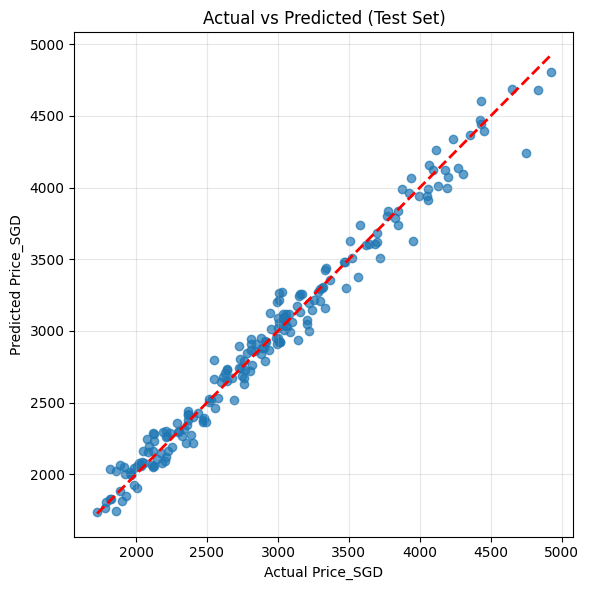


Top 10 worst prediction errors (by absolute error):
 y_actual      y_pred  signed_error  abs_error
  4751.72 4238.447133   -513.272867 513.272867
  3954.75 3627.625567   -327.124433 327.124433
  3006.98 3266.099200    259.119200 259.119200
  2549.66 2799.787767    250.127767 250.127767
  3025.14 3269.383200    244.243200 244.243200
  3218.19 2998.400467   -219.789533 219.789533
  1818.80 2034.974933    216.174933 216.174933
  3721.90 3511.822233   -210.077767 210.077767
  3005.97 3215.082000    209.112000 209.112000
  2995.14 3202.974033    207.834033 207.834033


In [41]:
# CODES to start modelling from Train/Test Split till Model Evaluation for 1 model only #

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor  # baseline tree-based regressor
import matplotlib.pyplot as plt


# -----------------------------
# 1) Split X and y
# -----------------------------
target_col = 'Price_SGD'
X = df.drop(columns=[target_col])
y = df[target_col]

# -----------------------------
# 2) Train/Test Split (test_size=0.2)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 3) Identify numerical and categorical columns
# -----------------------------
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.columns.difference(num_cols).tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# -----------------------------
# 4) Preprocessing pipeline
#    - StandardScaler for numerical
#    - OneHotEncoder for categorical
# -----------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

# -----------------------------
# 5) Train a simple baseline model
# -----------------------------
# Tree-based regression baseline (works well with preprocessing)
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

pipe.fit(X_train, y_train)

# -----------------------------
# 6) Evaluate and tabulate baseline (mae, rmse, r2) for train & test
# -----------------------------
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

y_pred_train = pipe.predict(X_train)
y_pred_test = pipe.predict(X_test)

train_mae, train_rmse, train_r2 = evaluate_regression(y_train, y_pred_train)
test_mae, test_rmse, test_r2 = evaluate_regression(y_test, y_pred_test)

results_table = pd.DataFrame({
    "Split": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2]
})

print("\nBaseline evaluation:")
print(results_table)

# -----------------------------
# 7) Predict on X_test and interpret results
# -----------------------------
pred_df = pd.DataFrame({
    "y_actual": y_test.values,
    "y_pred": y_pred_test,
})
pred_df["error"] = pred_df["y_pred"] - pred_df["y_actual"]
pred_df["abs_error"] = pred_df["error"].abs()

print("\nSample predictions (first 10 rows):")
print(pred_df.head(10))

print(
    "\nInterpretation (quick):\n"
    f"- Test MAE={test_mae:.3f} means predictions are off by ~{test_mae:.3f} SGD on average.\n"
    f"- Test RMSE={test_rmse:.3f} penalizes larger mistakes more heavily.\n"
    f"- Test R2={test_r2:.3f} indicates how much variance in Price_SGD is explained "
    f"by the model (1.0 is perfect; 0.0 ~ predicting the mean)."
)

# -----------------------------
# 8) Cross Validation using ShuffleSplit (5 splits), test_size=0.2
# -----------------------------
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# -----------------------------
# 9) Evaluate with cv_mae, cv_rmse, cv_r2
# -----------------------------
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

cv_out = cross_validate(
    pipe, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_metrics = pd.DataFrame({
    "metric": ["cv_mae", "cv_rmse", "cv_r2"],
    "mean": [
        -cv_out["test_mae"].mean(),
        -cv_out["test_rmse"].mean(),
        cv_out["test_r2"].mean()
    ],
    "std": [
        cv_out["test_mae"].std(ddof=0) * -1,   # neg -> revert sign
        cv_out["test_rmse"].std(ddof=0) * -1, # neg -> revert sign
        cv_out["test_r2"].std(ddof=0)
    ]
})

print("\nCross-validation results (ShuffleSplit, 5 splits):")
print(cv_metrics)

# Optional: show per-fold values
per_fold = pd.DataFrame({
    "fold": np.arange(1, len(cv_out["test_r2"]) + 1),
    "cv_mae": -cv_out["test_mae"],
    "cv_rmse": -cv_out["test_rmse"],
    "cv_r2": cv_out["test_r2"]
})
print("\nPer-fold CV metrics:")
print(per_fold)

# -----------------------------
# 10) Plot "Actual vs Predicted" scatter plot
# -----------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.7)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual Price_SGD")
plt.ylabel("Predicted Price_SGD")
plt.title("Actual vs Predicted (Test Set)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 11) Error analysis table: top 10 worst prediction errors
# -----------------------------
# Worst by absolute error (largest mistakes)
worst10 = pred_df.sort_values("abs_error", ascending=False).head(10).copy()

# Add directionality too
worst10["signed_error"] = worst10["error"]

print("\nTop 10 worst prediction errors (by absolute error):")
print(
    worst10[["y_actual", "y_pred", "signed_error", "abs_error"]]
    .to_string(index=False)
)



#<font color = 'red'>**Ask LLM to start modelling from Train/Test Split till Model Evaluation for 2 models only. Compare which model is better**

In [8]:
df = cleaned_df

sklearn_ver=sklearn.__version__
np_version = np.__version__
pd_version = pd.__version__
#mse = mean_squared_error(y_true, y_pred)
#rmse = np.sqrt(mse)

prompt_models = f"""
You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column 'Price_SGD'.
X and y for modelling where X is the input features without target and y is the target
Based on these versions {sklearn_ver} , {pd_version} and {np_version}, generate simple, executable Python codes:
1. Split X and y
2. Train/Test Split using test_size=0.2
3. Identify numerical and categorical columns
4. Create preprocessing pipeline using ColumnTransformer ( StandardScaler for numerical columns, onehotencoder for categorical columns)
5. Create and train 2 models, Random Forest and XGBoost
6. Evaluate, tabulate and compare both models (mae,rsme,r2) for train and test
7. Use the pipeline and the models to predict on X_test, and interpret the results
8. Perform Cross Validation using ShuffleSplit (5 splits) with the same test size (20%)
9. Evaluate, tabulate and compare the models using cv_mae, cv_rmse, cv_r2.
10. Based on the model with the best CV validation MAE, plot "Actual vs Predicted" scatter plot
11. Create error analysis table ( with absolute error and absolute percentage error) for the model with test set and sort by absolute_error shows top 10 largest errors

"""

print('=== Prompt to send ===')
print(prompt_model)

if client is not None:
    response_models = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_models
    )
    print('\n=== LLM response ===')
    print(response_models.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

NameError: name 'sklearn' is not defined

Numerical columns: ['RAM_GB', 'Storage_GB', 'Weight_kg', 'Screen_Size_inch']
Categorical columns: ['Brand', 'Model', 'CPU', 'GPU', 'Touchscreen']

=== Train/Test Evaluation ===
              Train_MAE  Train_RMSE  Train_R2   Test_MAE   Test_RMSE   Test_R2
Model                                                                         
RandomForest  35.316654   46.409212  0.996549  81.127728  105.656884  0.979668
XGBoost        4.677760    6.218314  0.999938  61.184033   83.940201  0.987167

Sample predictions (first 10 rows):
    Actual      RF_Pred     XGB_Pred
0  3056.76  3107.627767  3120.297607
1  2005.05  2058.361933  2008.528198
2  3299.06  3287.572333  3246.507324
3  2256.04  2191.405200  2231.199951
4  2722.71  2888.647533  2841.858398
5  3012.86  2917.801300  2999.113770
6  3135.26  3171.529000  3202.745117
7  2549.66  2797.327267  2725.479492
8  2303.14  2303.264500  2260.439453
9  2780.58  2838.294067  2853.079102

Best model on Test by MAE: XGBoost
Interpretation: The lower t

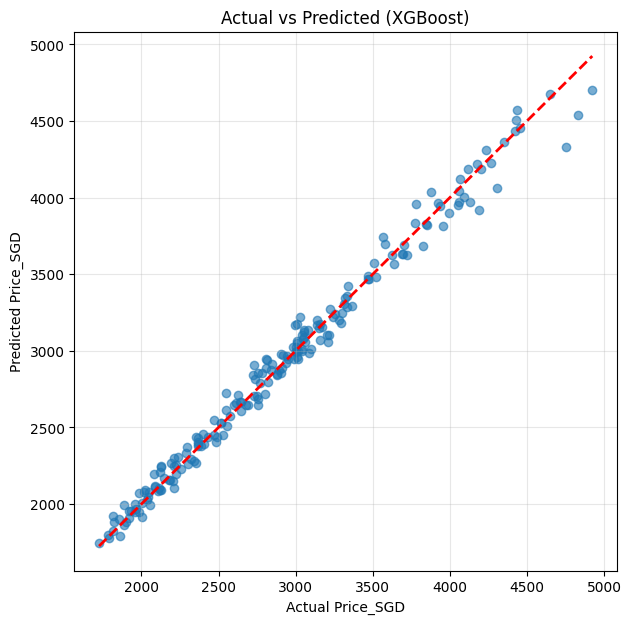

In [199]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, ShuffleSplit, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

# XGBoost
from xgboost import XGBRegressor

import matplotlib.pyplot as plt


# -------------------------
# 1-3. Split X/y and train-test, identify column types
# -------------------------
y = df['Price_SGD']
X = df.drop(columns=['Price_SGD'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify column types
numerical_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


# -------------------------
# 4. Preprocessing pipeline
# -------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop"
)


# -------------------------
# 5. Create and train 2 models (pipelines)
# -------------------------
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    objective="reg:squarederror"
)

rf_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", rf_model)])
xgb_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", xgb_model)])

rf_pipe.fit(X_train, y_train)
xgb_pipe.fit(X_train, y_train)


# -------------------------
# 6. Evaluate, tabulate and compare on train/test
# -------------------------
def eval_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

models = {
    "RandomForest": rf_pipe,
    "XGBoost": xgb_pipe
}

rows = []
for name, pipe in models.items():
    # Train
    y_pred_train = pipe.predict(X_train)
    mae_tr, rmse_tr, r2_tr = eval_regression(y_train, y_pred_train)

    # Test
    y_pred_test = pipe.predict(X_test)
    mae_te, rmse_te, r2_te = eval_regression(y_test, y_pred_test)

    rows.append({
        "Model": name,
        "Train_MAE": mae_tr,
        "Train_RMSE": rmse_tr,
        "Train_R2": r2_tr,
        "Test_MAE": mae_te,
        "Test_RMSE": rmse_te,
        "Test_R2": r2_te,
    })

results_df = pd.DataFrame(rows).set_index("Model")
print("\n=== Train/Test Evaluation ===")
print(results_df)


# -------------------------
# 7. Predict on X_test using the pipelines + interpret results
# -------------------------
# Example: create predictions and show a quick view
rf_pred = rf_pipe.predict(X_test)
xgb_pred = xgb_pipe.predict(X_test)

preds_compare = pd.DataFrame({
    "Actual": y_test.values,
    "RF_Pred": rf_pred,
    "XGB_Pred": xgb_pred
})

print("\nSample predictions (first 10 rows):")
print(preds_compare.head(10))

best_test_model = results_df["Test_MAE"].idxmin()
print(f"\nBest model on Test by MAE: {best_test_model}")
print(
    "Interpretation: The lower the MAE/RMSE and the higher the R2, "
    "the closer predictions are to actual prices on unseen data (X_test)."
)


# -------------------------
# 8-9. Cross Validation using ShuffleSplit (5 splits), test_size=0.2
# -------------------------
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# We'll use cross_validate with scoring functions
# (neg_* scores are returned as negative; we convert to positive in post-processing)
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

cv_rows = []
for name, pipe in models.items():
    cv_res = cross_validate(
        pipe,
        X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_rows.append({
        "Model": name,
        "cv_mae_mean": -cv_res["test_mae"].mean(),
        "cv_mae_std": cv_res["test_mae"].std(),
        "cv_rmse_mean": -cv_res["test_rmse"].mean(),
        "cv_rmse_std": cv_res["test_rmse"].std(),
        "cv_r2_mean": cv_res["test_r2"].mean(),
        "cv_r2_std": cv_res["test_r2"].std()
    })

cv_results_df = pd.DataFrame(cv_rows).set_index("Model")

print("\n=== Cross-Validation Evaluation (ShuffleSplit: 5 splits, 20% test) ===")
print(cv_results_df)

best_cv_model = cv_results_df["cv_mae_mean"].idxmin()
print(f"\nBest model by CV validation MAE: {best_cv_model}")


# -------------------------
# 10. Plot Actual vs Predicted scatter for the best CV model (on X_test)
# -------------------------
best_pipe = models[best_cv_model]
best_pred = best_pipe.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_pred, alpha=0.6)
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)

plt.xlabel("Actual Price_SGD")
plt.ylabel("Predicted Price_SGD")
plt.title(f"Actual vs Predicted ({best_cv_model})")
plt.grid(True, alpha=0.3)
plt.show()


#**<font color='red'> Based on the model and CV metrics to check with Model is the best**

In [1]:
# WHICH MODEL IS THE BEST #

prompt_choose = f"""
You are an expert data scientist with experience in tree-based regression models.

You are given the following information:
- {results_df}
- {cv_results_df}

1. Which model has lower CV validation MAE?
2. Is the train MAE much lower than the validation MAE?
3. Is the train-validation gap acceptable? What is the implication if test is much larger than validation?
4. Suggest specific hyperparameter directions (e.g., max_depth, min_child_weight, subsample, colsample_bytree, reg_alpha/reg_lambda, learning_rate) to reduce the train–validation gap for the better model
5. Does the holdout MAE support the CV result?
6. Are there overfitting issues?
7. Overall, which model is the best and explain why?
"""
print('=== Prompt to send ===')
print(prompt_choose)

if client is not None:
    response_choose = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_choose
    )
    print('\n=== LLM response ===')
    print(response_choose.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

NameError: name 'results_df' is not defined

In [138]:
# Choose the model with the best CV validation MAE
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

prompt_error = f"""
You are an expert data scientist with experience in tree-based regression models.
Generate simple executable Python codes to:
- create error table with error direction (such as over-predicted, under-predicted) and error magnitude (such as absolute, relative) for the best model {best_model_name}
- Sorting by absolute_error,  show top 10 largest mistakes first.
"""
print('=== Prompt to send ===')
print(prompt_error)
if client is not None:
    response_error = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt_error
    )
    print('\n=== LLM response ===')
    print(response_error.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.
Generate simple executable Python codes to:
- create error table with error direction (such as over-predicted, under-predicted) and error magnitude (such as absolute, relative) for the best model XGBoost
- Sorting by absolute_error,  show top 10 largest mistakes first.


=== LLM response ===
```python
# --- Simple, executable code for error table + sorting by absolute_error (top 10) ---
# Assumptions:
# - You already trained a "best" XGBoost regressor named: best_xgb
# - You have test data: X_test (features) and y_test (true target)
# - If your y_test is a pandas Series, its values are used automatically.

import numpy as np
import pandas as pd

# Predict with the best model
y_pred = best_xgb.predict(X_test)

# Ensure 1D arrays
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(y_pred).ravel()

# ----------------------------
# Error metrics + direction
# ----------------------

In [137]:
import numpy as np
import pandas as pd

# -----------------------------
# Inputs (edit these as needed)
# -----------------------------
# y_true: 1D array-like of true values (e.g., y_test)
# X_test: features for prediction (e.g., X_test)
# best_model: trained best XGBoost regression model (e.g., from xgboost.XGBRegressor)
#
# Example:
# y_pred = best_model.predict(X_test)

y_pred = best_model.predict(X_test)

y_true = np.asarray(y_true).ravel()
y_pred = np.asarray(y_pred).ravel()

# -----------------------------
# Error computations
# -----------------------------
abs_error = np.abs(y_pred - y_true)

# Relative error: handle y_true == 0 safely
# (You can change to np.where(y_true != 0, abs_error / abs(y_true), np.nan) if preferred)
rel_error = np.where(y_true != 0, abs_error / np.abs(y_true), np.nan)

# Direction:
# over-predicted: prediction > truth
# under-predicted: prediction < truth
# exact: equal
direction = np.where(y_pred > y_true, "over-predicted",
             np.where(y_pred < y_true, "under-predicted", "exact"))

# -----------------------------
# Create error table
# -----------------------------
error_table = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred,
    "absolute_error": abs_error,
    "relative_error": rel_error,
    "error_direction": direction
})

# Add row IDs (useful for debugging)
error_table.index.name = "row_id"
error_table = error_table.reset_index()

# -----------------------------
# Sorting by absolute_error:
# show top 10 largest mistakes first
# -----------------------------
top10 = (error_table
         .sort_values("absolute_error", ascending=False)
         .head(10))

# Display results
print("Top 10 largest mistakes (sorted by absolute_error):")
print(top10[[
    "row_id",
    "y_true",
    "y_pred",
    "error_direction",
    "absolute_error",
    "relative_error"
]].to_string(index=False))



ValueError: X has 20 features, but ColumnTransformer is expecting 9 features as input.